# Geometrische Verteilung und Exponentialverteilung

Die **Exponentialverteilung** ist die stetige Entsprechung der diskreten **geometrischen Verteilung**.
Beide modellieren *Wartezeiten bis zum ersten Ereignis*.

| | Geometrische Verteilung | Exponentialverteilung |
|---|---|---|
| Wertebereich | $k = 1, 2, 3, \\ldots$ | $x \\geq 0$ |
| Parameter | Erfolgswahrscheinlichkeit $p$ | Rate $\\lambda > 0$ |
| Erwartungswert | $1/p$ | $1/\\lambda$ |
| Varianz | $(1-p)/p^2$ | $1/\\lambda^2$ |
| Gedaechtnislosigkeit | ja | ja |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom, expon

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Module geladen.')


Module geladen.


## 1. Grenzuebergang: Geometrisch -> Exponential

Sei $p = \\lambda / n$ die Erfolgswahrscheinlichkeit pro Versuch und $n$ die Schritte pro Zeiteinheit.
Fuer $n \\to \\infty$ gilt:

$$P(X > k) = (1-p)^k = \\left(1 - \\frac{\\lambda}{n}\\right)^{n \\cdot t} \\xrightarrow{n \\to \\infty} e^{-\\lambda t}$$

Dies ist genau die **Ueberlebensfunktion** der Exponentialverteilung.


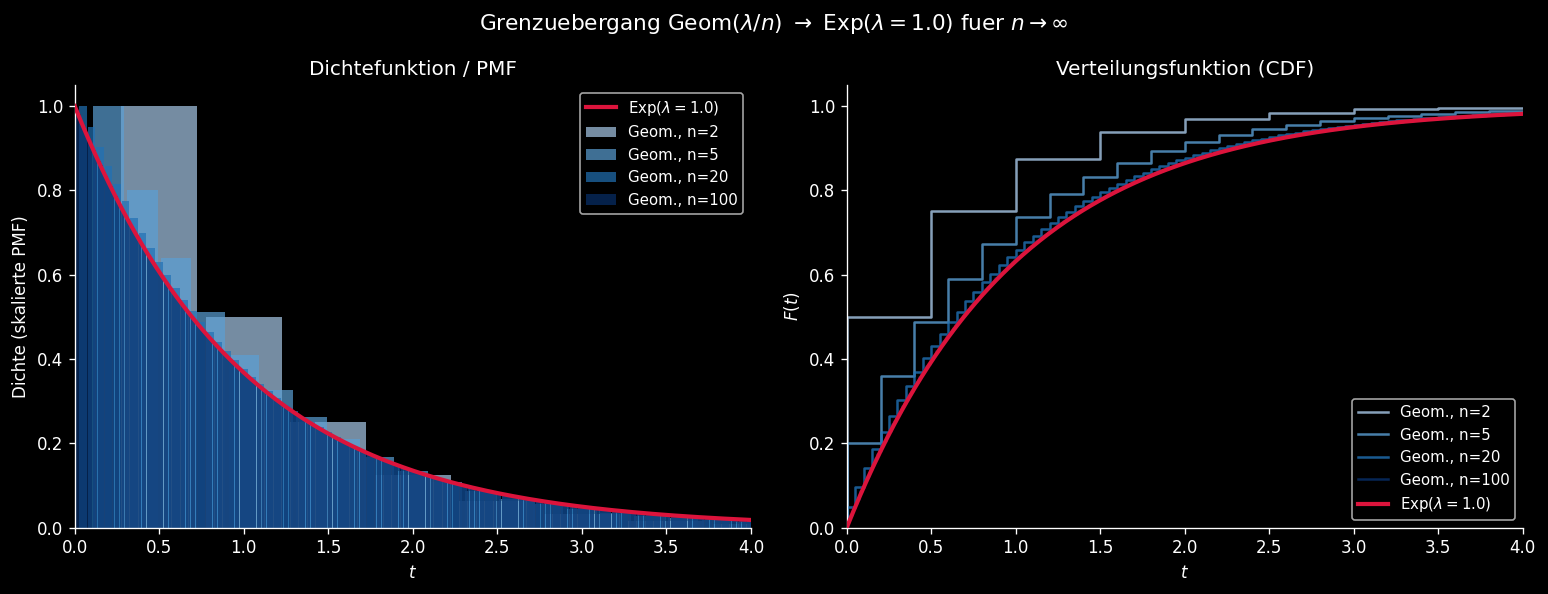

In [2]:
lam     = 1.0
n_werte = [2, 5, 20, 100]
colors  = ['#a8c8e8', '#5a9fd4', '#2171b5', '#08306b']
t_max   = 4.0
t       = np.linspace(0, t_max, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dichte / PMF
ax = axes[0]
for n, col in zip(n_werte, colors):
    p   = lam / n
    k   = np.arange(1, int(t_max * n) + 1)
    t_k = k / n
    ax.bar(t_k, geom.pmf(k, p) * n, width=1/n * 0.9,
           color=col, alpha=0.7, label=f'Geom., n={n}')
ax.plot(t, expon.pdf(t, scale=1/lam), 'crimson', lw=2.5, zorder=5,
        label=fr'Exp($\lambda={lam}$)')
ax.set_xlabel('$t$'); ax.set_ylabel('Dichte (skalierte PMF)')
ax.set_title('Dichtefunktion / PMF'); ax.legend(fontsize=9); ax.set_xlim(0, t_max)

# CDF
ax = axes[1]
for n, col in zip(n_werte, colors):
    p   = lam / n
    k   = np.arange(1, int(t_max * n) + 1)
    t_k = k / n
    ax.step(np.concatenate([[0], t_k]), np.concatenate([[0], geom.cdf(k, p)]),
            color=col, alpha=0.8, lw=1.5, label=f'Geom., n={n}')
ax.plot(t, expon.cdf(t, scale=1/lam), 'crimson', lw=2.5, zorder=5,
        label=fr'Exp($\lambda={lam}$)')
ax.set_xlabel('$t$'); ax.set_ylabel('$F(t)$')
ax.set_title('Verteilungsfunktion (CDF)'); ax.legend(fontsize=9)
ax.set_xlim(0, t_max); ax.set_ylim(0, 1.05)

fig.suptitle(fr'Grenzuebergang Geom($\lambda/n$) $\to$ Exp($\lambda={lam}$) fuer $n \to \infty$',
             fontsize=13)
plt.tight_layout(); plt.show()


## 2. Direkter Vergleich bei festem $p$ und $\\lambda = p$

Fuer kleine $p$ stimmen geometrische PMF und Exponential-PDF gut ueberein,
wenn man $\\lambda = p$ setzt.


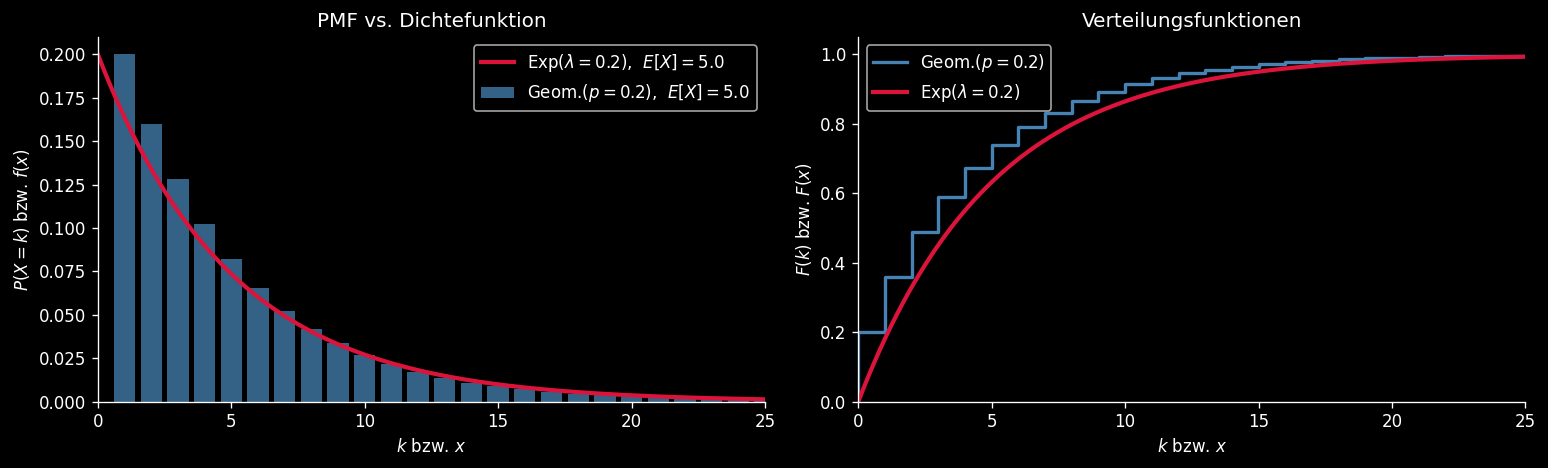

In [3]:
# --- Parameter anpassen ---
p = 0.2
# --------------------------

lam   = p
k_max = int(5 / lam)
k     = np.arange(1, k_max + 1)
x     = np.linspace(0, k_max, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(k, geom.pmf(k, p), color='steelblue', alpha=0.75,
       label=fr'Geom.($p={p}$),  $E[X]={1/p:.1f}$')
ax.plot(x, expon.pdf(x, scale=1/lam), 'crimson', lw=2.5,
        label=fr'Exp($\lambda={lam}$),  $E[X]={1/lam:.1f}$')
ax.set_xlabel('$k$ bzw. $x$'); ax.set_ylabel('$P(X=k)$ bzw. $f(x)$')
ax.set_title('PMF vs. Dichtefunktion')
ax.legend(fontsize=10); ax.set_xlim(0, k_max)

ax = axes[1]
ax.step(np.concatenate([[0], k]), np.concatenate([[0], geom.cdf(k, p)]),
        color='steelblue', lw=2, label=fr'Geom.($p={p}$)')
ax.plot(x, expon.cdf(x, scale=1/lam), 'crimson', lw=2.5,
        label=fr'Exp($\lambda={lam}$)')
ax.set_xlabel('$k$ bzw. $x$'); ax.set_ylabel('$F(k)$ bzw. $F(x)$')
ax.set_title('Verteilungsfunktionen')
ax.legend(fontsize=10); ax.set_xlim(0, k_max); ax.set_ylim(0, 1.05)

plt.tight_layout(); plt.show()


## 3. Gedaechtnislosigkeit

Beide Verteilungen besitzen die **Gedaechtnislosigkeit**:

$$P(X > s + t \\mid X > s) = P(X > t)$$

Fuer die Exponentialverteilung laesst sich dies direkt nachrechnen:

$$P(X > s+t \\mid X > s)
= \\frac{P(X > s+t)}{P(X > s)}
= \\frac{e^{-\\lambda(s+t)}}{e^{-\\lambda s}}
= e^{-\\lambda t} = P(X > t)$$


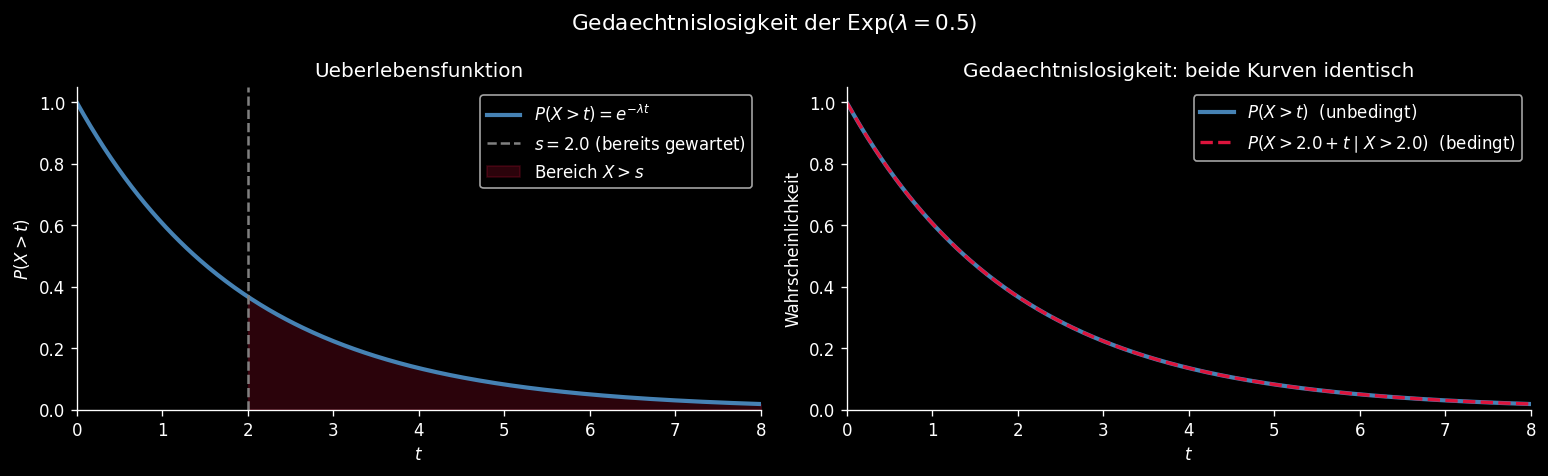

In [4]:
lam = 0.5
s   = 2.0   # bereits gewartet
t   = np.linspace(0, 8, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(t, np.exp(-lam * t), 'steelblue', lw=2.5, label=r'$P(X > t) = e^{-\lambda t}$')
ax.axvline(s, color='gray', ls='--', lw=1.5, label=f'$s = {s}$ (bereits gewartet)')
ax.fill_between(t[t >= s], np.exp(-lam * t[t >= s]),
                alpha=0.2, color='crimson', label=r'Bereich $X > s$')
ax.set_xlabel('$t$'); ax.set_ylabel(r'$P(X > t)$')
ax.set_title('Ueberlebensfunktion')
ax.legend(fontsize=10); ax.set_xlim(0, 8); ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(t, np.exp(-lam * t), 'steelblue', lw=2.5, label=r'$P(X > t)$  (unbedingt)')
ax.plot(t, np.exp(-lam * t), 'crimson',   lw=2,   ls='--',
        label=fr'$P(X > {s}+t \mid X > {s})$  (bedingt)')
ax.set_xlabel('$t$'); ax.set_ylabel('Wahrscheinlichkeit')
ax.set_title('Gedaechtnislosigkeit: beide Kurven identisch')
ax.legend(fontsize=10); ax.set_xlim(0, 8); ax.set_ylim(0, 1.05)

fig.suptitle(fr'Gedaechtnislosigkeit der Exp($\lambda={lam}$)', fontsize=13)
plt.tight_layout(); plt.show()


## 4. Einfluss von $\\lambda$ auf die Exponentialverteilung

$\\lambda$ gibt die mittlere **Ereignisrate** an:
grosses $\\lambda$ = kurze Wartezeiten, kleines $\\lambda$ = lange Wartezeiten.


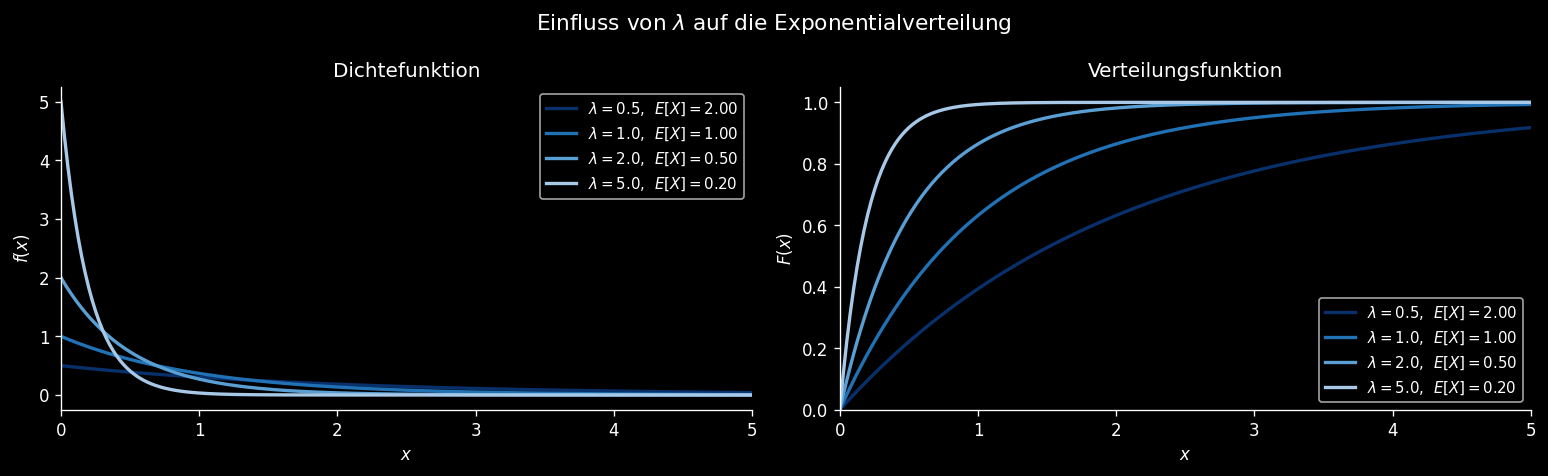

In [5]:
lam_werte = [0.5, 1.0, 2.0, 5.0]
colors    = ['#08306b', '#2171b5', '#5a9fd4', '#a8c8e8']
x         = np.linspace(0, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lam, col in zip(lam_werte, colors):
    lbl = fr'$\lambda={lam}$,  $E[X]={1/lam:.2f}$'
    axes[0].plot(x, expon.pdf(x, scale=1/lam), color=col, lw=2, label=lbl)
    axes[1].plot(x, expon.cdf(x, scale=1/lam), color=col, lw=2, label=lbl)

axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$f(x)$')
axes[0].set_title('Dichtefunktion'); axes[0].set_xlim(0, 5); axes[0].legend(fontsize=9)

axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$F(x)$')
axes[1].set_title('Verteilungsfunktion')
axes[1].set_xlim(0, 5); axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9)

fig.suptitle(r'Einfluss von $\lambda$ auf die Exponentialverteilung', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Zusammenfassung

| Eigenschaft | Geom.$(p)$ | Exp$(\\lambda)$ |
|---|---|---|
| PMF / PDF | $P(X=k) = (1-p)^{k-1}\\, p$ | $f(x) = \\lambda\\, e^{-\\lambda x}$ |
| CDF | $F(k) = 1-(1-p)^k$ | $F(x) = 1-e^{-\\lambda x}$ |
| Ueberlebensfunktion | $(1-p)^k$ | $e^{-\\lambda x}$ |
| Gedaechtnislosigkeit | ja | ja |
| Grenzuebergang | $p = \\lambda/n,\\; n \\to \\infty$ | Grenzwert |

**Fazit:** Die Exponentialverteilung entsteht aus der geometrischen durch den Grenzuebergang
zu immer feineren Zeitschritten ($n \\to \\infty$ bei $p = \\lambda/n$).
Beide teilen die Gedaechtnislosigkeit -- eine Eigenschaft, die unter allen stetigen
Verteilungen nur die Exponentialverteilung besitzt.
